
# 1. Entendimiento del Negocio y los Datos (EDA)
## Dataset: Data Science Salaries 2023

**Objetivo de negocio:** Ayudar a empresas y profesionales a entender los factores que determinan los salarios en el campo de Data Science, para tomar decisiones informadas de contratación y negociación salarial.

**Objetivo analítico:** Construir un modelo de regresión que prediga `salary_in_usd` a partir de variables como nivel de experiencia, tipo de empleo, rol, tamaño de empresa y país.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

# Cargar datos (descarga desde Kaggle primero)
df = pd.read_csv('ds_salaries.csv')
print('Shape:', df.shape)
df.head()

Shape: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [18]:
print('TIPOS DE DATOS')
print(df.dtypes)
print('VALORES NULOS')
print(df.isnull().sum())
print('ESTADÍSTICAS DESCRIPTIVAS')
df.describe(include='all')

TIPOS DE DATOS
work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object
VALORES NULOS
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64
ESTADÍSTICAS DESCRIPTIVAS


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
count,3755.000000,3755,3755,3755,3.755000e+03,3755,3755.000000,3755,3755.000000,3755,3755
unique,NaN,4,4,93,NaN,20,NaN,78,NaN,72,3
top,NaN,SE,FT,Data Engineer,NaN,USD,NaN,US,NaN,US,M
freq,NaN,2516,3718,1040,NaN,3224,NaN,3004,NaN,3040,3153
mean,2022.373635,NaN,NaN,NaN,1.906956e+05,NaN,137570.389880,NaN,46.271638,NaN,NaN
std,0.691448,NaN,NaN,NaN,6.716765e+05,NaN,63055.625278,NaN,48.589050,NaN,NaN
min,2020.000000,NaN,NaN,NaN,6.000000e+03,NaN,5132.000000,NaN,0.000000,NaN,NaN
25%,2022.000000,NaN,NaN,NaN,1.000000e+05,NaN,95000.000000,NaN,0.000000,NaN,NaN
50%,2022.000000,NaN,NaN,NaN,1.380000e+05,NaN,135000.000000,NaN,0.000000,NaN,NaN
75%,2023.000000,NaN,NaN,NaN,1.800000e+05,NaN,175000.000000,NaN,100.000000,NaN,NaN


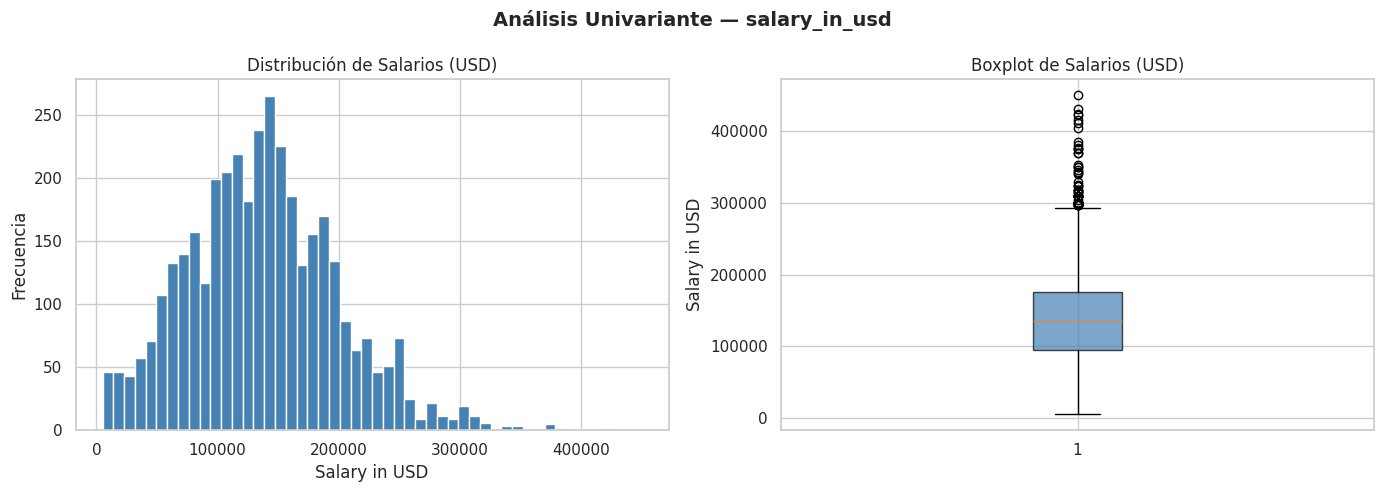

Media: $137,570
Mediana: $135,000
Std: $63,056
Min: $5,132 | Max: $450,000


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['salary_in_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Salarios (USD)')
axes[0].set_xlabel('Salary in USD')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['salary_in_usd'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot de Salarios (USD)')
axes[1].set_ylabel('Salary in USD')

plt.suptitle('Análisis Univariante — salary_in_usd', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Media: ${df["salary_in_usd"].mean():,.0f}')
print(f'Mediana: ${df["salary_in_usd"].median():,.0f}')
print(f'Std: ${df["salary_in_usd"].std():,.0f}')
print(f'Min: ${df["salary_in_usd"].min():,.0f} | Max: ${df["salary_in_usd"].max():,.0f}')

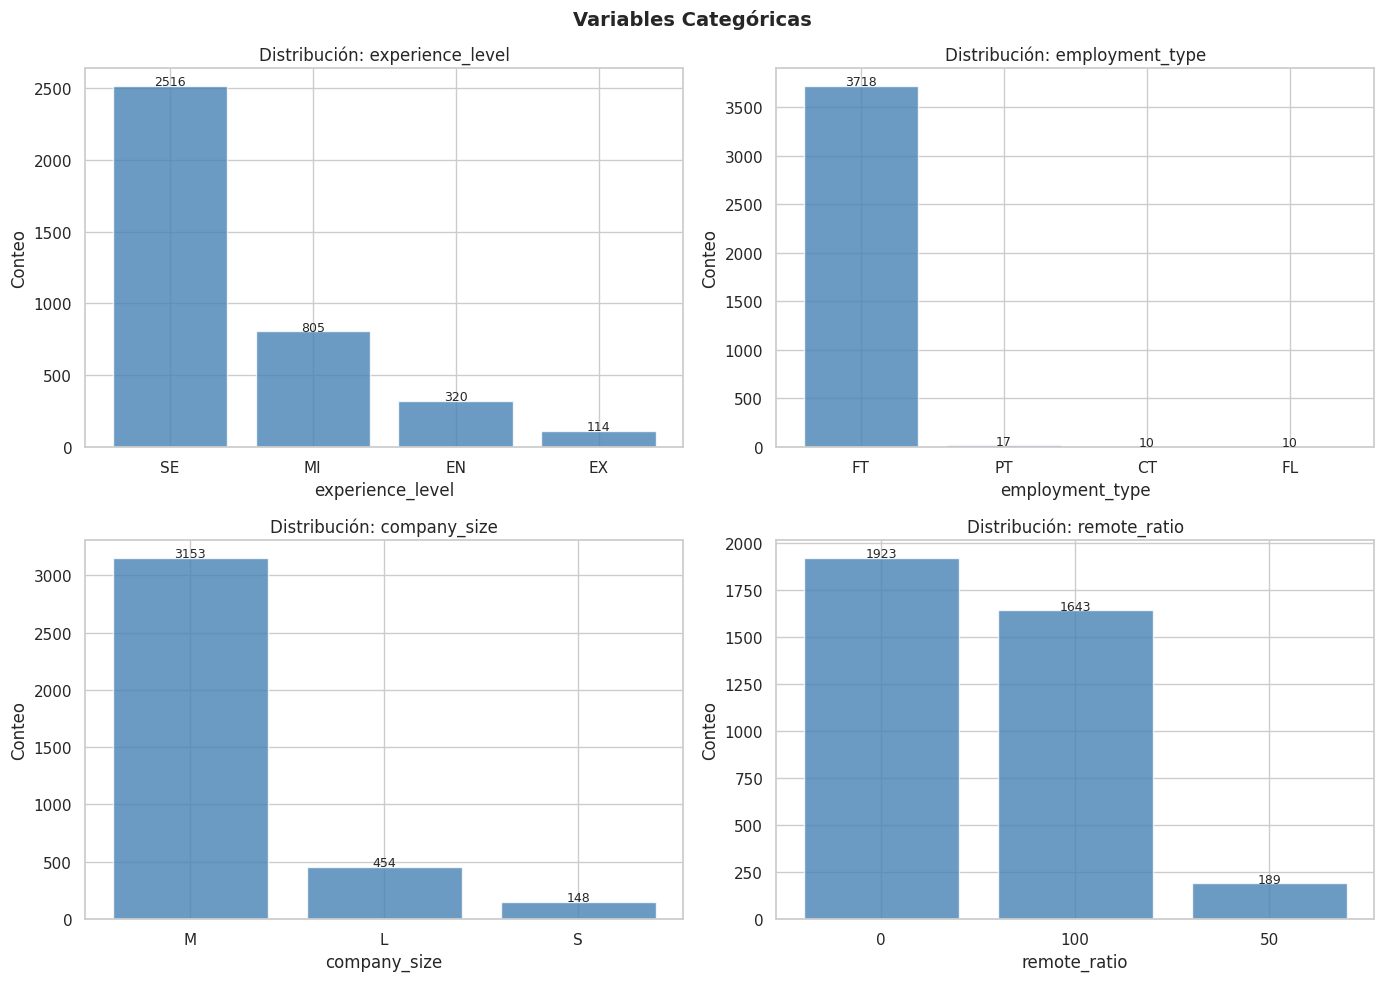

In [15]:
cat_cols = ['experience_level', 'employment_type', 'company_size', 'remote_ratio']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Conteo')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=9)

plt.suptitle('Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

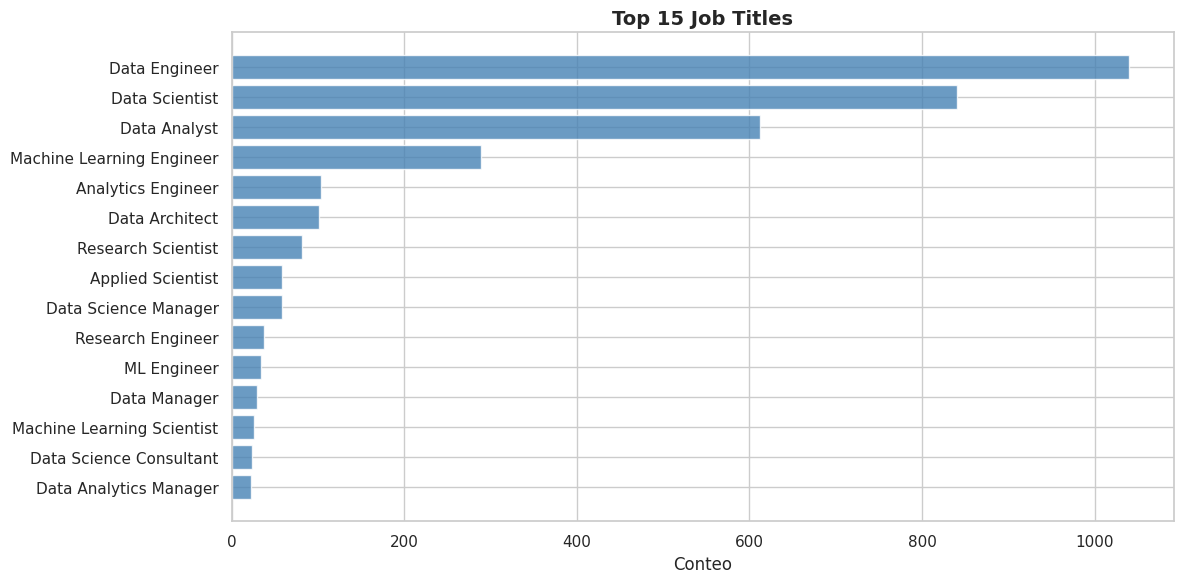

In [14]:
top_jobs = df['job_title'].value_counts().head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_jobs.index[::-1], top_jobs.values[::-1], color='steelblue', alpha=0.8)
plt.title('Top 15 Job Titles', fontsize=14, fontweight='bold')
plt.xlabel('Conteo')
plt.tight_layout()
plt.savefig('images/eda_jobs.png', dpi=150, bbox_inches='tight')
plt.show()

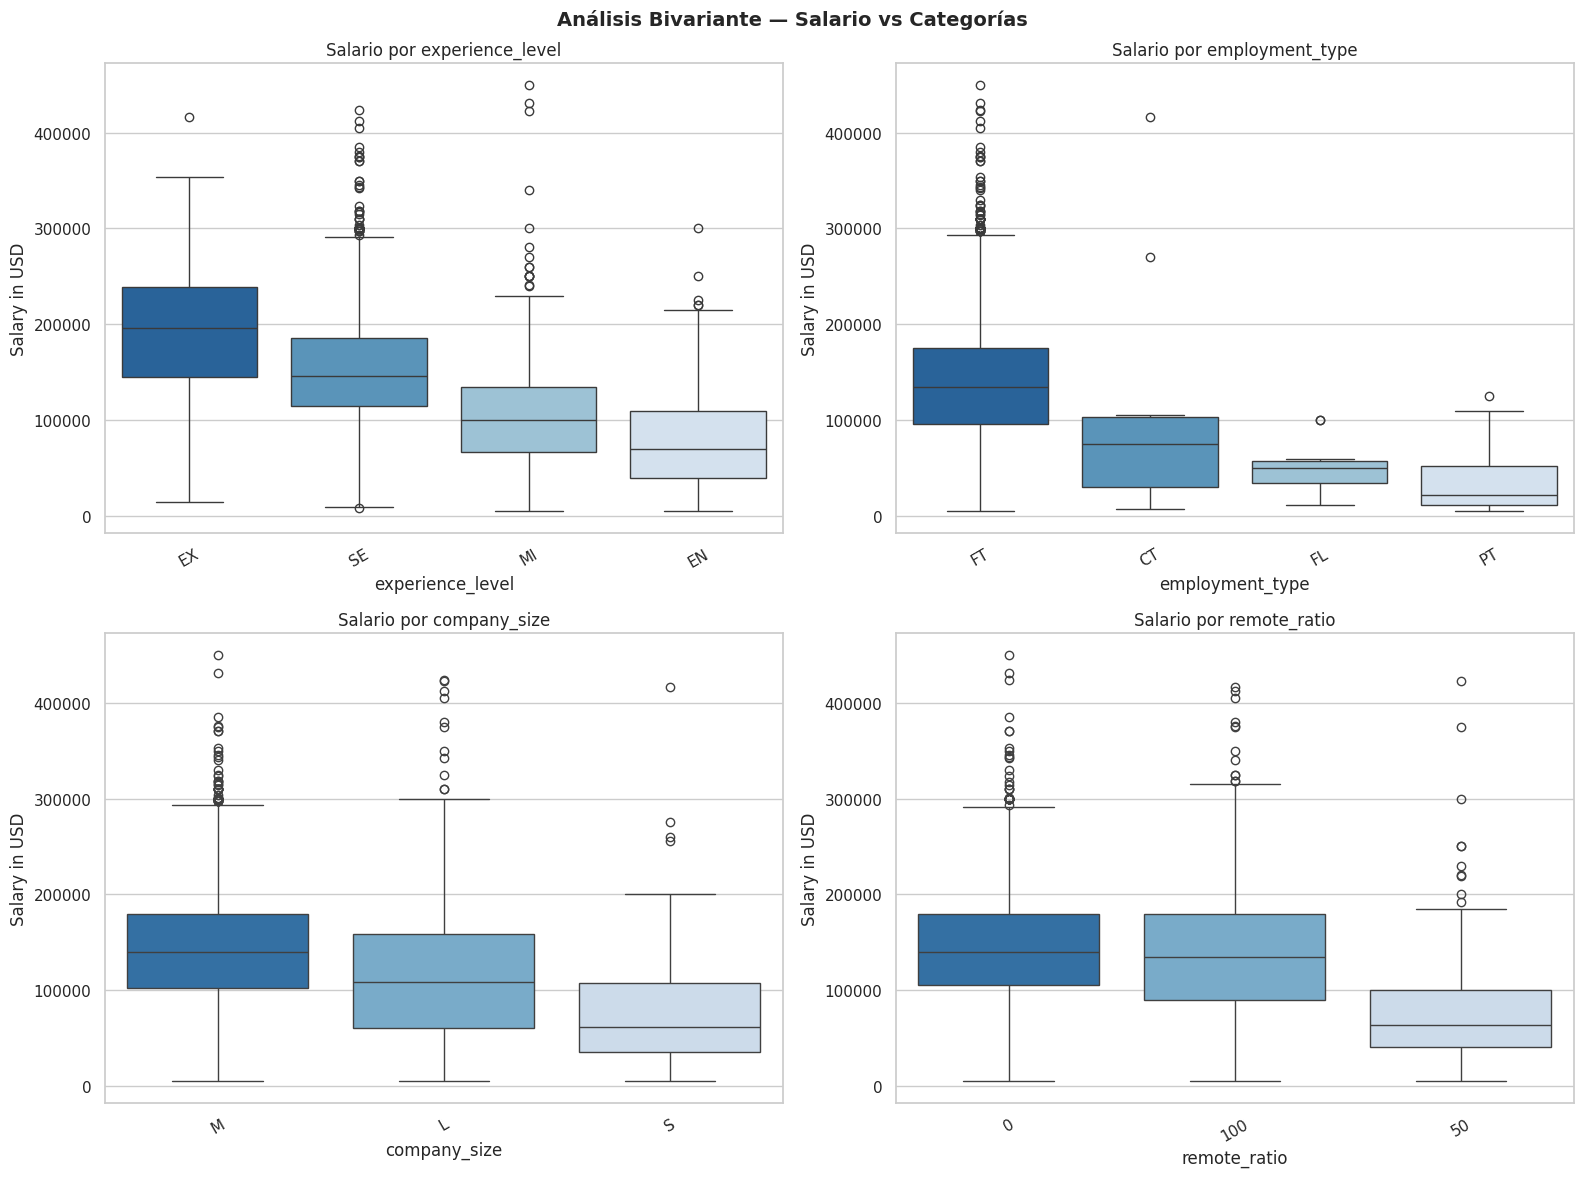

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df.groupby(col)['salary_in_usd'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='salary_in_usd', order=order, ax=axes[i],
                palette='Blues_r')
    axes[i].set_title(f'Salario por {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Salary in USD')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Análisis Bivariante — Salario vs Categorías', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_bivariante.png', dpi=150, bbox_inches='tight')
plt.show()

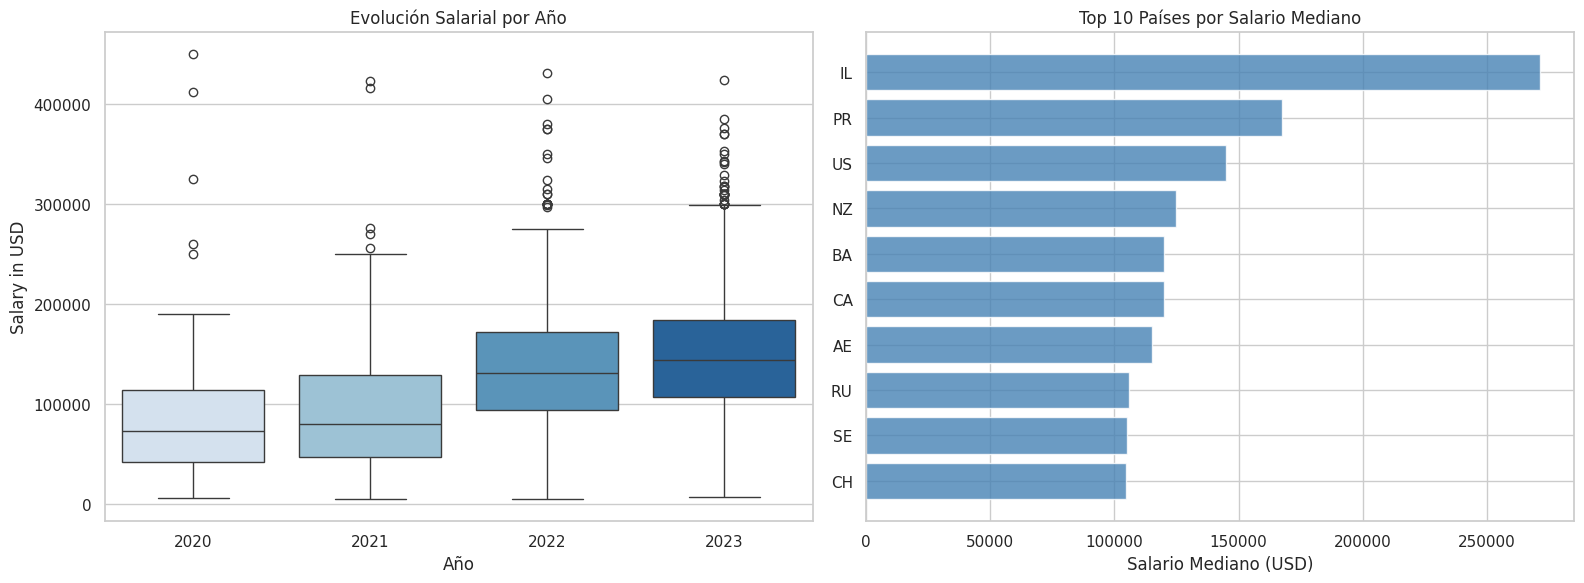

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Salario por año
sns.boxplot(data=df, x='work_year', y='salary_in_usd', ax=axes[0], palette='Blues')
axes[0].set_title('Evolución Salarial por Año')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Salary in USD')

# Top 10 países por salario mediano
top_countries = (df.groupby('company_location')['salary_in_usd']
                   .median().sort_values(ascending=False).head(10))
axes[1].barh(top_countries.index[::-1], top_countries.values[::-1],
             color='steelblue', alpha=0.8)
axes[1].set_title('Top 10 Países por Salario Mediano')
axes[1].set_xlabel('Salario Mediano (USD)')

plt.tight_layout()
plt.savefig('images/eda_year_country.png', dpi=150, bbox_inches='tight')
plt.show()

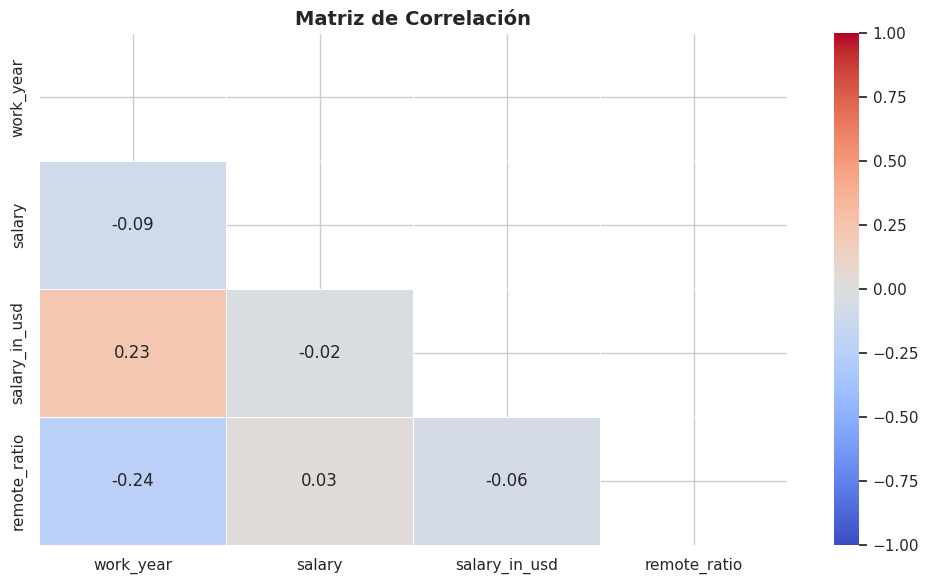

In [17]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()